In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import copy
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [37]:
df= pd.read_csv('diamonds.csv')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [39]:
df = pd.get_dummies(df, drop_first=True)
X = df.drop(columns=['price']).values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [40]:
df

,carat,depth,table,x,y,z,price,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,326,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,326,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,327,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,334,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,335,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,2757,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,2757,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,2757,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,2757,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [41]:
X_tr = torch.FloatTensor(X_train)
y_tr = torch.FloatTensor(y_train).reshape(-1, 1)
X_te = torch.FloatTensor(X_test)
y_te = torch.FloatTensor(y_test)
X_v = torch.FloatTensor(X_val)
y_v = torch.FloatTensor(y_val).reshape(-1, 1)

In [42]:
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
val_dataset = torch.utils.data.TensorDataset(X_v, y_v)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [43]:
class NeuralNet2(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_classes=1,
        dropout=0.2
    ):
        super(NeuralNet2, self).__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden_size
        )

        self.ln1 = nn.LayerNorm(
            hidden_size
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            p=dropout
        )

        self.fc2 = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        out = self.fc1(x)
        out = self.ln1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

In [44]:
class PyTorchRegressor(
    BaseEstimator,
    RegressorMixin
):

    def __init__(
        self,
        hidden_size=64,
        dropout=0.2,
        learning_rate=0.01,
        batch_size=256,
        num_epochs=50,
        patience=5,
        log_dir="runs/diamonds"
    ):

        self.hidden_size = hidden_size
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.num_epochs = num_epochs
        self.patience = patience
        self.log_dir = log_dir


    def fit(
        self,
        X,
        y,
        X_val=None,
        y_val=None
    ):

        X = np.asarray(
            X,
            dtype=np.float32
        )

        y = np.asarray(
            y,
            dtype=np.float32
        )

        if X_val is not None:

            X_val = np.asarray(
                X_val,
                dtype=np.float32
            )

            y_val = np.asarray(
                y_val,
                dtype=np.float32
            )


        self.scaler_y_ = StandardScaler()

        y_scaled = self.scaler_y_.fit_transform(
            y.reshape(-1, 1)
        ).ravel()


        if y_val is not None:

            y_val_scaled = self.scaler_y_.transform(
                y_val.reshape(-1, 1)
            ).ravel()


        X_tensor = torch.FloatTensor(
            X
        )

        y_tensor = torch.FloatTensor(
            y_scaled
        ).reshape(-1, 1)


        # Validation tensors

        if X_val is not None:

            X_val_tensor = torch.FloatTensor(
                X_val
            )

            y_val_tensor = torch.FloatTensor(
                y_val_scaled
            ).reshape(-1, 1)


        train_dataset = torch.utils.data.TensorDataset(
            X_tensor,
            y_tensor
        )


        if X_val is not None:

            val_dataset = torch.utils.data.TensorDataset(
                X_val_tensor,
                y_val_tensor
            )

        train_loader = torch.utils.data.DataLoader(
            dataset=train_dataset,
            batch_size=self.batch_size,
            shuffle=True
        )


        if X_val is not None:

            val_loader = torch.utils.data.DataLoader(
                dataset=val_dataset,
                batch_size=self.batch_size,
                shuffle=False
            )

        self.model_ = NeuralNet2(
            input_size=X.shape[1],
            hidden_size=self.hidden_size,
            num_classes=1,
            dropout=self.dropout
        )

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            self.model_.parameters(),
            lr=self.learning_rate
        )

        self.writer_ = SummaryWriter(
            log_dir=self.log_dir
        )

        self.writer_.add_graph(
            self.model_,
            X_tensor[:1]
        )

        best_val_loss = float('inf')

        counter = 0

        best_model = None

        self.loss_history_ = []

        self.val_loss_history_ = []


        for epoch in range(self.num_epochs):


            self.model_.train()

            epoch_loss = 0

            for features, labels in train_loader:

                # Forward
                outputs = self.model_(
                    features
                )

                # Loss
                loss = criterion(
                    outputs,
                    labels
                )


                # Zero gradients
                optimizer.zero_grad()


                # Backpropagation
                loss.backward()


                # Update weights
                optimizer.step()


                epoch_loss += loss.item()

            avg_loss = (
                epoch_loss /
                len(train_loader)
            )


            self.loss_history_.append(
                avg_loss
            )


            self.model_.eval()

            val_loss = 0


            with torch.no_grad():

                for features, labels in val_loader:

                    outputs = self.model_(
                        features
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    val_loss += loss.item()


            avg_val_loss = (
                val_loss /
                len(val_loader)
            )


            self.val_loss_history_.append(
                avg_val_loss
            )

            print(
                f"Epoch [{epoch + 1}/{self.num_epochs}], "
                f"Train Loss: {avg_loss:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}"
            )


            self.writer_.add_scalar(
                "Loss/Train",
                avg_loss,
                epoch
            )

            self.writer_.add_scalar(
                "Loss/Validation",
                avg_val_loss,
                epoch
            )

            self.writer_.add_scalar(
                "Learning Rate",
                optimizer.param_groups[0]['lr'],
                epoch
            )

            if avg_val_loss < best_val_loss:

                best_val_loss = avg_val_loss

                counter = 0

                best_model = copy.deepcopy(
                    self.model_.state_dict()
                )


            else:

                counter += 1

                print(
                    f"No improvement: "
                    f"{counter}/{self.patience}"
                )


                if counter >= self.patience:

                    print(
                        "Early stopping!"
                    )

                    break

        self.model_.load_state_dict(
            best_model
        )

        self.writer_.close()


        return self

    def predict(self, X):

        X = np.asarray(
            X,
            dtype=np.float32
        )


        X_tensor = torch.FloatTensor(
            X
        )


        self.model_.eval()


        with torch.no_grad():

            predictions = self.model_(
                X_tensor
            )


        predictions = predictions.numpy()

        predictions = self.scaler_y_.inverse_transform(
            predictions
        )


        return predictions.ravel()


In [45]:
pipeline = Pipeline([

    (
        'scaler',
        StandardScaler()
    ),

    (
        'model',
        PyTorchRegressor(
            hidden_size=64,
            dropout=0.2,
            learning_rate=0.01,
            batch_size=256,
            num_epochs=50,
            patience=5,
            log_dir="runs/diamonds"
        )
    )
])

pipeline.fit(
    X_train,
    y_train,
    model__X_val=X_val,
    model__y_val=y_val
)


pred = pipeline.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    pred
)

mse = mean_squared_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mse
)

r2 = r2_score(
    y_test,
    pred
)

print(
    f"MAE:  {mae:.4f}"
)

print(
    f"MSE:  {mse:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R²:   {r2:.4f}"
)


Epoch [1/50], Train Loss: 0.1124, Val Loss: 0.0319
Epoch [2/50], Train Loss: 0.0534, Val Loss: 0.0309
Epoch [3/50], Train Loss: 0.0472, Val Loss: 0.0293
Epoch [4/50], Train Loss: 0.0437, Val Loss: 0.0348
No improvement: 1/5
Epoch [5/50], Train Loss: 0.0430, Val Loss: 0.0248
Epoch [6/50], Train Loss: 0.0411, Val Loss: 0.0249
No improvement: 1/5
Epoch [7/50], Train Loss: 0.0402, Val Loss: 0.0235
Epoch [8/50], Train Loss: 0.0408, Val Loss: 0.0232
Epoch [9/50], Train Loss: 0.0381, Val Loss: 0.0230
Epoch [10/50], Train Loss: 0.0388, Val Loss: 0.0235
No improvement: 1/5
Epoch [11/50], Train Loss: 0.0391, Val Loss: 0.0239
No improvement: 2/5
Epoch [12/50], Train Loss: 0.0378, Val Loss: 0.0230
Epoch [13/50], Train Loss: 0.0378, Val Loss: 0.0225
Epoch [14/50], Train Loss: 0.0380, Val Loss: 0.0257
No improvement: 1/5
Epoch [15/50], Train Loss: 0.0350, Val Loss: 0.0222
Epoch [16/50], Train Loss: 0.0361, Val Loss: 0.0238
No improvement: 1/5
Epoch [17/50], Train Loss: 0.0362, Val Loss: 0.0235
No im

In [46]:
model_wrapper = (
    pipeline
    .named_steps['model']
)


loss_history = (
    model_wrapper
    .loss_history_
)

val_loss_history = (
    model_wrapper
    .val_loss_history_
)


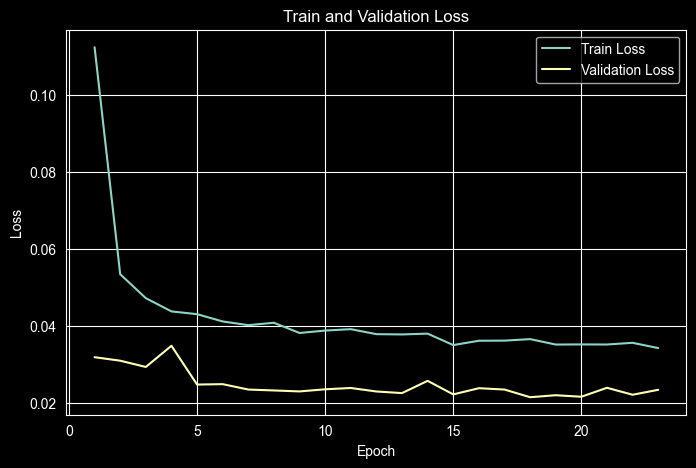

In [48]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    range(
        1,
        len(loss_history) + 1
    ),
    loss_history,
    label='Train Loss'
)


plt.plot(
    range(
        1,
        len(val_loss_history) + 1
    ),
    val_loss_history,
    label='Validation Loss'
)


plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss'
)

plt.title(
    'Train and Validation Loss'
)

plt.legend()

plt.grid(True)

plt.show()